In [1]:
import io
import os
import sys
import pickle

import h5py
import numpy as np
import networkx as nx
import random
import tqdm
from PIL import Image
import re


In [2]:
def load_episode_from_hdf5_with_actions(hdf5_path: str, episode_id: str) -> dict:
    """
    Read one episode back from the HDF5 file.

    Returns a dict with keys:
        episode_id              : str
        instruction             : str
        graph                   : unpickled networkx graph
        frame_data              : list of dicts, each with keys:
                                      frame_idx, rgb,
                                      masks           [K, H, W] uint8
                                      class_ids       [K]       int64
                                      instance_ids    [K]       int64
                                      e3d_distances   [K]       float32
                                      next_action     int  (0-3)
                                      next_action_instruction  str
    """
    episode_id = str(episode_id)

    with h5py.File(hdf5_path, "r") as hf:
        if episode_id not in hf:
            raise KeyError(f"Episode '{episode_id}' not found in {hdf5_path}")

        ep_grp = hf[episode_id]

        raw_instr = ep_grp["instruction"][()]
        instruction = raw_instr.decode("utf-8") if isinstance(raw_instr, bytes) else str(raw_instr)

        graph_bytes = ep_grp["graph"][()].tobytes()
        graph = pickle.loads(graph_bytes)

        frame_data = []
        frames_grp = ep_grp["frames"]
        for frame_key in sorted(frames_grp.keys()):
            fg = frames_grp[frame_key]
            raw_nai = fg["next_action_instruction"][()]
            nai = raw_nai.decode("utf-8") if isinstance(raw_nai, bytes) else str(raw_nai)
            frame_data.append({
                "frame_idx":               int(fg["frame_idx"][()]),
                "rgb":                     fg["rgb"][()],
                "masks":                   fg["masks"][()]         if "masks"         in fg else None,
                "class_ids":               fg["class_ids"][()]     if "class_ids"     in fg else None,
                "instance_ids":            fg["instance_ids"][()]  if "instance_ids"  in fg else None,
                "e3d_distances":           fg["e3d_distances"][()] if "e3d_distances" in fg else None,
                "next_action":             int(fg["next_action"][()]) if "next_action" in fg else 0,
                "next_action_instruction": nai,
            })

    return {
        "episode_id":  episode_id,
        "instruction": instruction,
        "graph":       graph,
        "frame_data":  frame_data,
    }


### Distrinution of Object only and wo object instruction

In [3]:
hdf5_path= "/media/opervu-user/Data2/ws/data_langgeonet_e3d_action/e3d_action_train_ep500.h5"
excluded = {""}
from collections import Counter

with h5py.File(hdf5_path, "r") as hf:
    ep_ids = hf.keys()
    total_count = 0        # ← moved outside
    obj_counter = Counter() # ← moved outside

    for episode_id in ep_ids:
        if episode_id not in hf:
            raise KeyError(f"Episode '{episode_id}' not found in {hdf5_path}")

        ep_grp = hf[episode_id]
        raw_instr = ep_grp["instruction"][()]
        instruction = raw_instr.decode("utf-8") if isinstance(raw_instr, bytes) else str(raw_instr)

        graph_bytes = ep_grp["graph"][()].tobytes()
        graph = pickle.loads(graph_bytes)

        frames_grp = ep_grp["frames"]

        for frame_key in sorted(frames_grp.keys()):
            total_count += 1
            fg = frames_grp[frame_key]
            raw_nai = fg["next_action_instruction"][()]
            nai = raw_nai.decode("utf-8") if isinstance(raw_nai, bytes) else str(raw_nai)
            words = re.findall(r'\b\w+\b', nai.lower())
            if len(words) > 3 and not excluded.intersection(words):
                last_word = words[-1]
                obj_counter[last_word] += 1

print(f"Total frames: {total_count}")
print(f"Frames with object reference: {sum(obj_counter.values())}\n")
print("Object reference percentages:")
for obj, count in obj_counter.most_common():
    print(f"  {obj}: {count} ({(count / total_count) * 100:.2f}%)")

Total frames: 46551
Frames with object reference: 33478

Object reference percentages:
  door: 9540 (20.49%)
  picture: 3109 (6.68%)
  chair: 3105 (6.67%)
  window: 2586 (5.56%)
  cabinet: 2243 (4.82%)
  stairs: 1748 (3.76%)
  table: 1652 (3.55%)
  shelving: 1241 (2.67%)
  curtain: 1096 (2.35%)
  counter: 1077 (2.31%)
  cushion: 966 (2.08%)
  plant: 732 (1.57%)
  fireplace: 481 (1.03%)
  appliances: 474 (1.02%)
  bed: 449 (0.96%)
  mirror: 381 (0.82%)
  towel: 333 (0.72%)
  seating: 318 (0.68%)
  sofa: 302 (0.65%)
  shower: 293 (0.63%)
  stool: 259 (0.56%)
  chest_of_drawers: 229 (0.49%)
  bathtub: 182 (0.39%)
  sink: 153 (0.33%)
  tv_monitor: 146 (0.31%)
  clothes: 122 (0.26%)
  furniture: 88 (0.19%)
  toilet: 61 (0.13%)
  gym_equipment: 41 (0.09%)
  destination: 40 (0.09%)
  blinds: 27 (0.06%)
  board_panel: 4 (0.01%)


### serious stuff

In [4]:
h5_path= "/media/opervu-user/Data2/ws/data_langgeonet_e3d_action/e3d_action_train_ep500.h5"
episode_id= 8548

In [ ]:
## Split h5 into train and test

import h5py
import numpy as np

src_path   = "/media/opervu-user/Data2/ws/data_langgeonet_e3d_action/e3d_action_train_ep500_stratified.h5"
train_path = "/media/opervu-user/Data2/ws/data_langgeonet_e3d_action/train_ep500_stratified.h5"
test_path  = "/media/opervu-user/Data2/ws/data_langgeonet_e3d_action/test_ep500_stratified.h5"
test_ratio = 0.2
seed       = 42

with h5py.File(src_path, "r") as src:
    ep_ids = sorted(src.keys())

rng = np.random.default_rng(seed)
ep_ids = rng.permutation(ep_ids).tolist()

n_test  = max(1, int(len(ep_ids) * test_ratio))
test_ids  = set(ep_ids[:n_test])
train_ids = set(ep_ids[n_test:])

print(f"Total episodes : {len(ep_ids)}")
print(f"Train episodes : {len(train_ids)}")
print(f"Test  episodes : {len(test_ids)}")

def _copy_episodes(src_path, dst_path, ep_ids):
    with h5py.File(src_path, "r") as src, h5py.File(dst_path, "w") as dst:
        for ep_id in ep_ids:
            src.copy(src[ep_id], dst, name=ep_id)
    print(f"  Written {len(ep_ids)} episodes → {dst_path}")

_copy_episodes(src_path, train_path, train_ids)
_copy_episodes(src_path, test_path,  test_ids)
print("Done.")


Total episodes : 500
Train episodes : 400
Test  episodes : 100
  Written 400 episodes → /media/opervu-user/Data2/ws/data_langgeonet_e3d_action/train_ep500.h5
  Written 100 episodes → /media/opervu-user/Data2/ws/data_langgeonet_e3d_action/test_ep500.h5
Done.


In [5]:
episode_data= load_episode_from_hdf5_with_actions(h5_path, episode_id)

In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patheffects import withStroke
import numpy as np

ACTION_NAMES   = {0: "Stop", 1: "Move Forward", 2: "Turn Left", 3: "Turn Right"}
ACTION_COLOURS = {0: "#e74c3c", 1: "#2ecc71", 2: "#3498db", 3: "#f39c12"}

# MP3D 40-class category names (index → name)
MP3D_CATS = {
    0:"void", 1:"wall", 2:"floor", 3:"chair", 4:"door", 5:"table",
    6:"picture", 7:"cabinet", 8:"cushion", 9:"window", 10:"sofa",
    11:"bed", 12:"curtain", 13:"chest_of_drawers", 14:"plant", 15:"sink",
    16:"stairs", 17:"ceiling", 18:"toilet", 19:"stool", 20:"towel",
    21:"mirror", 22:"tv_monitor", 23:"shower", 24:"column", 25:"bathtub",
    26:"counter", 27:"fireplace", 28:"lighting", 29:"beam", 30:"railing",
    31:"shelving", 32:"blinds", 33:"gym_equipment", 34:"seating",
    35:"board_panel", 36:"furniture", 37:"appliances", 38:"clothes", 39:"objects",
}


def _graph_e3d_costs(G) -> tuple[np.ndarray, dict]:
    """
    Compute per-node **intra-frame** Dijkstra cost from G.graph['all_paths_lengths'].

    For each node n in frame f:
        intra_cost[n] = mean( all_paths_lengths[n, m]
                              for all m in same frame f,  m != n,
                              where distance < 1e5 )

    This uses the full precomputed Dijkstra shortest-path distances
    (edge weight = e3d), but restricts the averaging to co-visible nodes only.

    Returns
    -------
    node_costs : (N,) float32  — raw mean intra-frame Dijkstra distance (metres)
    frame_map  : dict  frame_idx → {local_obj_idx: graph_node_rank}
    """
    apl   = np.asarray(G.graph["all_paths_lengths"], dtype=np.float32)  # (N, N)
    nodes = list(G.nodes())
    N     = len(nodes)

    # Build frame → [list of node ranks]
    frame_ranks: dict = {}
    for rank, n in enumerate(nodes):
        m = G.nodes[n].get("map")
        if m is not None:
            frame_ranks.setdefault(int(m[0]), []).append(rank)

    node_costs = np.zeros(N, dtype=np.float32)
    for ranks in frame_ranks.values():
        ranks_arr = np.array(ranks)
        for rank in ranks:
            # Dijkstra distances from this node to all co-frame nodes
            peer_ranks = ranks_arr[ranks_arr != rank]
            if peer_ranks.size == 0:
                continue
            dists  = apl[rank, peer_ranks]
            finite = dists[dists < 1e5]
            node_costs[rank] = float(finite.mean()) if finite.size else 0.0

    frame_map: dict = {}
    for rank, n in enumerate(nodes):
        m = G.nodes[n].get("map")
        if m is not None:
            fidx, local_idx = int(m[0]), int(m[1])
            frame_map.setdefault(fidx, {})[local_idx] = rank

    return node_costs, frame_map


def visualize_frame_e3d_heatmap(
    episode_data: dict,
    frame_idx: int = None,
    alpha: float = 0.60,
    cmap_name: str = "RdYlBu_r",
) -> None:
    """
    Render a heatmap where each mask pixel's colour encodes the object's
    **intra-frame Dijkstra cost**: the mean Dijkstra shortest-path distance
    (edge weight = Euclidean 3D distance, metres) from that node to every
    other co-visible node in the same frame.

    Low cost  (blue) → close to co-visible objects  (scene-central)
    High cost (red)  → far from co-visible objects  (peripheral)
    """
    G      = episode_data["graph"]
    frames = episode_data["frame_data"]

    valid = [f for f in frames
             if f.get("masks") is not None and len(f["masks"]) > 0]
    if not valid:
        print("No frames with mask data.")
        return

    if frame_idx is None:
        fd = random.choice(valid)
    else:
        fd = next((f for f in frames if f["frame_idx"] == frame_idx),
                  random.choice(valid))

    rgb         = fd["rgb"].astype(np.uint8)   # (H, W, 3)
    masks       = fd["masks"]                  # (K, H, W) uint8
    class_ids   = fd.get("class_ids")          # (K,) int64 | None
    next_action = fd["next_action"]
    nai         = fd["next_action_instruction"]
    H, W        = rgb.shape[:2]
    K           = len(masks)

    # ── 1. Intra-frame Dijkstra costs ─────────────────────────────────────
    node_costs, frame_map = _graph_e3d_costs(G)

    fnodes  = frame_map.get(int(fd["frame_idx"]), {})
    raw_e3d = np.zeros(K, dtype=np.float32)
    for local_idx in range(K):
        rank = fnodes.get(local_idx)
        if rank is not None:
            raw_e3d[local_idx] = node_costs[rank]

    lo, hi   = float(raw_e3d.min()), float(raw_e3d.max())
    norm_e3d = (raw_e3d - lo) / (hi - lo) if hi > lo else np.zeros(K, dtype=np.float32)

    # ── 2. Dense cost canvas (NaN = unmasked pixel) ───────────────────────
    cost_canvas = np.full((H, W), np.nan, dtype=np.float32)
    for k in range(K):
        bm = masks[k].astype(bool)
        cost_canvas[bm] = norm_e3d[k]

    # ── 3. RGBA heatmap composite ──────────────────────────────────────────
    cmap = cm.get_cmap(cmap_name)
    rgba = cmap(cost_canvas)
    rgba[np.isnan(cost_canvas)] = (0, 0, 0, 0)
    rgba[..., 3] = np.where(np.isnan(cost_canvas), 0.0, alpha)

    rgb_f     = rgb.astype(np.float32) / 255.0
    a         = rgba[..., 3:4]
    composite = np.clip(rgba[..., :3] * a + rgb_f * (1 - a), 0, 1)

    # ── 4. Centroid annotations ────────────────────────────────────────────
    centroids, labels_txt, label_colours = [], [], []
    for k in range(K):
        bm = masks[k].astype(bool)
        if not bm.any():
            continue
        ys, xs = np.where(bm)
        centroids.append((int(xs.mean()), int(ys.mean())))
        cat_id   = int(class_ids[k]) if class_ids is not None else -1
        cat_name = MP3D_CATS.get(cat_id, f"id{cat_id}")
        labels_txt.append(f"{cat_name}\n{raw_e3d[k]:.2f}m")
        label_colours.append(cmap(norm_e3d[k])[:3])

    # ── 5. Plot ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor="#1a1a2e")
    for ax in axes:
        ax.set_facecolor("#1a1a2e")

    axes[0].imshow(rgb)
    axes[0].set_title("RGB", color="white", fontsize=13, pad=8)
    axes[0].axis("off")

    axes[1].imshow(composite)
    axes[1].axis("off")

    outline = [withStroke(linewidth=2, foreground="black")]
    for (cx, cy), txt, col in zip(centroids, labels_txt, label_colours):
        axes[1].text(
            cx, cy, txt,
            ha="center", va="center", fontsize=7, color="white",
            path_effects=outline,
            bbox=dict(boxstyle="round,pad=0.15", fc=(*col, 0.55), ec="none"),
        )

    act_col  = ACTION_COLOURS.get(int(next_action), "#ffffff")
    act_name = ACTION_NAMES.get(int(next_action), str(next_action))
    axes[1].text(
        W / 2, H - 18,
        f"▶  Next: {act_name}  —  \"{nai}\"",
        ha="center", va="bottom", fontsize=11,
        color=act_col, fontweight="bold", path_effects=outline,
    )
    axes[1].set_title(
        f"Intra-frame Dijkstra e3d heatmap  ·  frame {fd['frame_idx']}  ·  {K} instances  "
        f"(blue = scene-central, red = peripheral)",
        color="white", fontsize=11, pad=8,
    )

    sm = cm.ScalarMappable(cmap=cmap_name, norm=mcolors.Normalize(lo, hi))
    sm.set_array([])
    cb = plt.colorbar(sm, ax=axes[1], fraction=0.025, pad=0.02)
    cb.set_label("mean intra-frame Dijkstra distance (metres)",
                 color="white", fontsize=9)
    cb.ax.yaxis.set_tick_params(color="white")
    plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")
    cb.outline.set_edgecolor("white")

    plt.suptitle(
        f"Episode {episode_data['episode_id']}  |  "
        f"Instruction: \"{episode_data['instruction'][:120]}\"",
        color="#cccccc", fontsize=9, y=1.005,
    )
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_2668372/1957116341.py:131: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


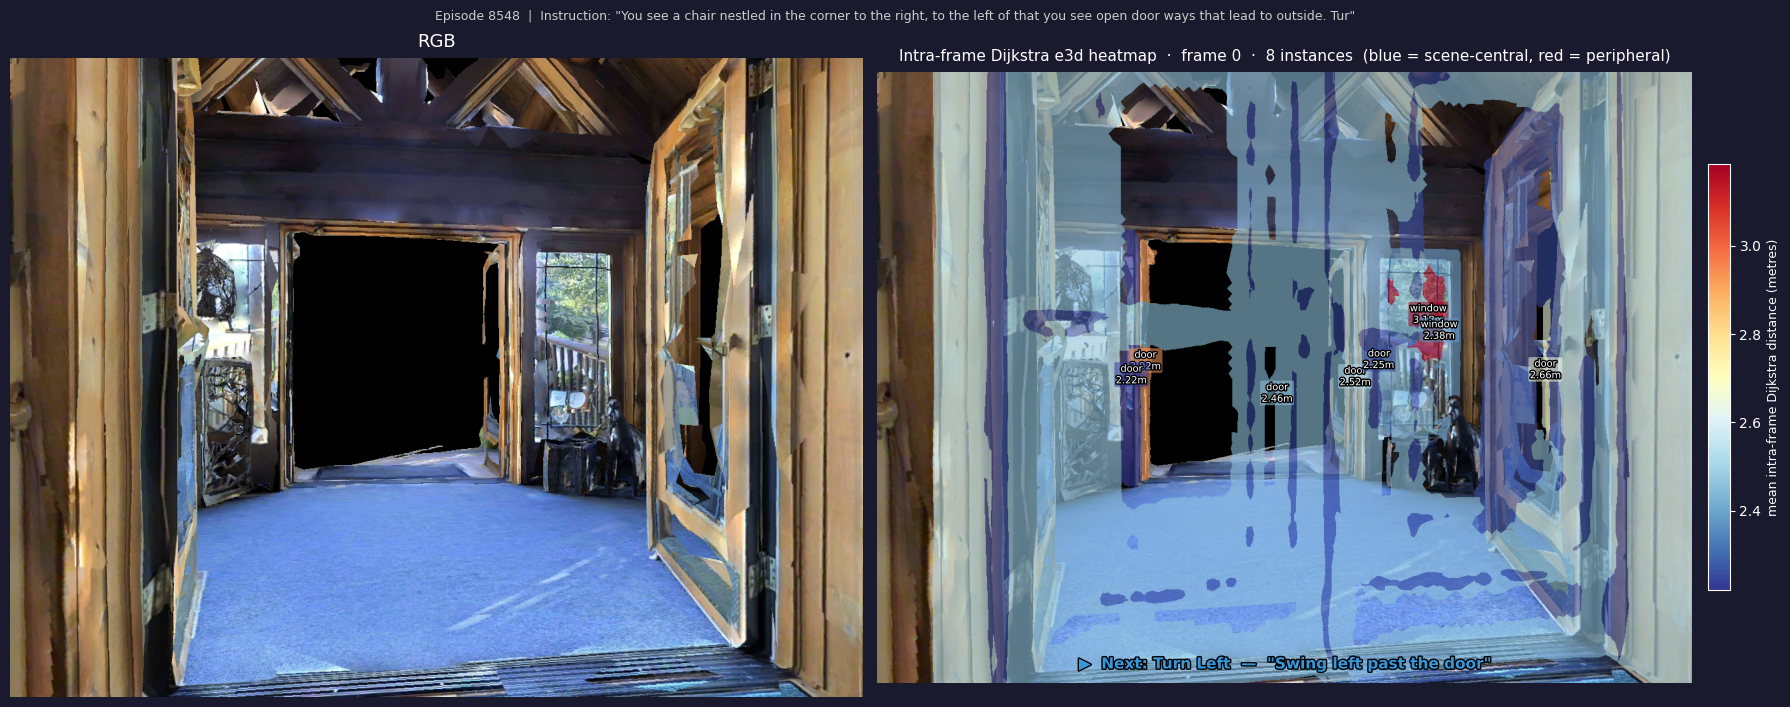

In [7]:
visualize_frame_e3d_heatmap(episode_data, frame_idx=0)   # None → random frame
